In [1]:
import numpy as np
import numpy as np
import pickle as pkl
import networkx as nx
import scipy.sparse as sp
#from scipy.sparse.linalg.eigen.arpack import eigsh
from scipy.sparse.linalg import eigsh


In [2]:
import sys
import re
from graph import Graph

In [3]:
def parse_index_file(filename):
    """Parse index file."""
    index = []
    for line in open(filename):
        index.append(int(line.strip()))
    return index


def sample_mask(idx, l):
    """Create mask."""
    mask = np.zeros(l)
    mask[idx] = 1
    return np.array(mask, dtype=np.bool)



In [4]:

def load_corpus(f_file, dataset_str):
    """
    Loads input corpus from gcn/data directory

    ind.dataset_str.x => the feature vectors of the train docs as scipy.sparse.csr.csr_matrix object;
    ind.dataset_str.tx => the feature vectors of the test docs as scipy.sparse.csr.csr_matrix object;
    ind.dataset_str.allx => the feature vectors of both labeled and unlabeled train docs/words
        (a superset of ind.dataset_str.x) as scipy.sparse.csr.csr_matrix object;
    ind.dataset_str.y => the one-hot labels of the labeled train docs as numpy.ndarray object;
    ind.dataset_str.ty => the one-hot labels of the test docs as numpy.ndarray object;
    ind.dataset_str.ally => the labels for instances in ind.dataset_str.allx as numpy.ndarray object;
    ind.dataset_str.adj => adjacency matrix of word/doc nodes as scipy.sparse.csr.csr_matrix object;
    ind.dataset_str.train.index => the indices of train docs in original doc list.

    All objects above must be saved using python pickle module.

    :param dataset_str: CAAprop name
    :return: All data input files loaded (as well the train/test data).
    """

    names = ['x', 'y', 'tx', 'ty', 'allx', 'ally', 'adj', 'adj1', 'adj2']
    objects = []
    for i in range(len(names)):
        with open(f_file + "/ind.{}.{}".format(dataset_str+"_new", names[i]), 'rb') as f:
            # if sys.version_info > (3, 0):
            #     objects.append(pkl.load(f, encoding='latin1'))
            # else:
                objects.append(pkl.load(f))

    x, y, tx, ty, allx, ally, adj, adj1, adj2 = tuple(objects)
    print(x.shape, y.shape, tx.shape, ty.shape, allx.shape, ally.shape)
    features = sp.vstack((allx, tx)).tolil()

    labels = np.vstack((ally, ty))

    train_idx_orig = parse_index_file(f_file + "/{}.train.index".format(dataset_str+"_new"))
    train_size = len(train_idx_orig)


    val_size = train_size - x.shape[0]
    test_size = tx.shape[0]

    idx_train = range(len(y))
    idx_val = range(len(y), len(y) + val_size)
    idx_test = range(allx.shape[0], allx.shape[0] + test_size)

    train_mask = sample_mask(idx_train, labels.shape[0])
    val_mask = sample_mask(idx_val, labels.shape[0])
    test_mask = sample_mask(idx_test, labels.shape[0])

    y_train = np.zeros(labels.shape)
    y_val = np.zeros(labels.shape)
    y_test = np.zeros(labels.shape)
    y_train[train_mask, :] = labels[train_mask, :]
    y_val[val_mask, :] = labels[val_mask, :]
    y_test[test_mask, :] = labels[test_mask, :]


    adj = adj + adj.T.multiply(adj.T > adj) - adj.multiply(adj.T > adj)
    adj1 = adj1 + adj1.T.multiply(adj1.T > adj1) - adj1.multiply(adj1.T > adj1)
    adj2 = adj2 + adj2.T.multiply(adj2.T > adj2) - adj2.multiply(adj2.T > adj2)

    return adj, adj1, adj2, features, y_train, y_val, y_test, train_mask, val_mask, test_mask, len(idx_train), len(idx_val),len(idx_test)



In [5]:

def sparse_to_tuple(sparse_mx):
    """Convert sparse matrix to tuple representation."""
    def to_tuple(mx):
        if not sp.isspmatrix_coo(mx):
            mx = mx.tocoo()
        coords = np.vstack((mx.row, mx.col)).transpose()
        values = mx.data
        shape = mx.shape
        return coords, values, shape

    if isinstance(sparse_mx, list):
        for i in range(len(sparse_mx)):
            sparse_mx[i] = to_tuple(sparse_mx[i])
    else:
        sparse_mx = to_tuple(sparse_mx)

    return sparse_mx


def preprocess_features(features):
    """Row-normalize feature matrix and convert to tuple representation"""
    rowsum = np.array(features.sum(1))
    r_inv = np.power(rowsum, -1).flatten()
    r_inv[np.isinf(r_inv)] = 0.
    r_mat_inv = sp.diags(r_inv)
    features = r_mat_inv.dot(features)
    return sparse_to_tuple(features)


def normalize_adj(adj):
    """Symmetrically normalize adjacency matrix."""
    adj = sp.coo_matrix(adj)
    rowsum = np.array(adj.sum(1))
    d_inv_sqrt = np.power(rowsum, -0.5).flatten()
    d_inv_sqrt[np.isinf(d_inv_sqrt)] = 0.
    d_mat_inv_sqrt = sp.diags(d_inv_sqrt)
    return adj.dot(d_mat_inv_sqrt).transpose().dot(d_mat_inv_sqrt).tocoo()


In [6]:

def preprocess_adj(adj):
    """Preprocessing of adjacency matrix for simple GCN model and conversion to tuple representation."""
    adj_normalized = normalize_adj(adj + sp.eye(adj.shape[0]))
    return sparse_to_tuple(adj_normalized)

def preprocess_adj_mix(adj):
    adj_normalized = adj + sp.eye(adj.shape[0])
    return sparse_to_tuple(adj)


def construct_feed_dict(features, labels, labels_mask, placeholders):
    """Construct feed dictionary."""
    feed_dict = dict()
    feed_dict.update({placeholders['labels']: labels})
    feed_dict.update({placeholders['labels_mask']: labels_mask})
    feed_dict.update({placeholders['features']: features})
    feed_dict.update({placeholders['num_features_nonzero']: features[1].shape})
    return feed_dict


def chebyshev_polynomials(adj, k):
    """Calculate Chebyshev polynomials up to order k. Return a list of sparse matrices (tuple representation)."""
    print("Calculating Chebyshev polynomials up to order {}...".format(k))

    adj_normalized = normalize_adj(adj)
    laplacian = sp.eye(adj.shape[0]) - adj_normalized
    largest_eigval, _ = eigsh(laplacian, 1, which='LM')
    scaled_laplacian = (
        2. / largest_eigval[0]) * laplacian - sp.eye(adj.shape[0])

    t_k = list()
    t_k.append(sp.eye(adj.shape[0]))
    t_k.append(scaled_laplacian)

    def chebyshev_recurrence(t_k_minus_one, t_k_minus_two, scaled_lap):
        s_lap = sp.csr_matrix(scaled_lap, copy=True)
        return 2 * s_lap.dot(t_k_minus_one) - t_k_minus_two

    for i in range(2, k+1):
        t_k.append(chebyshev_recurrence(t_k[-1], t_k[-2], scaled_laplacian))

    return sparse_to_tuple(t_k)


In [7]:

def loadWord2Vec(filename):
    """Read Word Vectors"""
    vocab = []
    embd = []
    word_vector_map = {}
    file = open(filename, 'r',encoding="utf-8")
    for line in file.readlines():
        row = line.strip().split(' ')
        if(len(row) > 2):
            vocab.append(row[0])
            vector = row[1:]
            length = len(vector)
            for i in range(length):
                vector[i] = float(vector[i])
            embd.append(vector)
            word_vector_map[row[0]] = vector
    print('Loaded Word Vectors!')
    file.close()
    return vocab, embd, word_vector_map

def clean_str(string):
    """
    Tokenization/string cleaning for all datasets except for SST.
    Original taken from https://github.com/yoonkim/CNN_sentence/blob/master/process_data.py
    """
    string = re.sub(r"[^A-Za-z0-9(),!?\'\`]", " ", string)
    string = re.sub(r"\'s", " \'s", string)
    string = re.sub(r"\'ve", " \'ve", string)
    string = re.sub(r"n\'t", " n\'t", string)
    string = re.sub(r"\'re", " \'re", string)
    string = re.sub(r"\'d", " \'d", string)
    string = re.sub(r"\'ll", " \'ll", string)
    string = re.sub(r",", " , ", string)
    string = re.sub(r"!", " ! ", string)
    string = re.sub(r"\(", " \( ", string)
    string = re.sub(r"\)", " \) ", string)
    string = re.sub(r"\?", " \? ", string)
    string = re.sub(r"\s{2,}", " ", string)
    return string.strip().lower()

def read_graph_from_adj(adj,dataset_name,graph):
    '''Assume idx starts from *1* and are continuous. Edge shows up twice. Assume single connected component.'''
#    logging.info("Reading graph_only_2.txt from metis...")
    with open("../../data_tgcn/"+dataset_name+"/build_train/ind.{}.{}".format(dataset_name+"_new", graph), 'rb') as f:
        if sys.version_info > (3, 0):
            in_file = pkl.load(f, encoding='latin1')
        else:
            in_file = pkl.load(f)
    # print(type(adj))#propaganda2:<class 'scipy.sparse.csr.csr_matrix'> cora:<class 'scipy.sparse.csr.csr_matrix'>
    weighted = False
    node_num = adj.shape[0]
    edge_num = np.count_nonzero(adj.toarray()) * 2
    graph = Graph(node_num, edge_num)
    edge_cnt = 0
    graph.adj_idx[0] = 0
    for idx in range(node_num):
        graph.node_wgt[idx] = 1
        eles = in_file[idx]
        j = 0
        while j < len(eles):
            neigh = int(eles[j])  #
            if weighted:
                wgt = float(eles[j+1])
            else:
                wgt = 1.0
            graph.adj_list[edge_cnt] = neigh # self-loop included.
            graph.adj_wgt[edge_cnt] = wgt
            graph.degree[idx] += wgt
            edge_cnt += 1
            if weighted:
                j += 2
            else:
                j += 1
        graph.adj_idx[idx+1] = edge_cnt
    graph.A = graph_to_adj(graph, self_loop=False)
    # check connectivity in debug mode
    # if ctrl.debug_mode:
    #     assert nx.is_connected(graph2nx(graph_only_2.txt))
    return graph, None
def graph_to_adj(graph, self_loop=False):
    '''self_loop: manually add self loop or not'''
    node_num = graph.node_num
    i_arr = []
    j_arr = []
    data_arr = []
    for i in range(0, node_num):
        for neigh_idx in range(graph.adj_idx[i], graph.adj_idx[i+1]):
            i_arr.append(i)
            j_arr.append(graph.adj_list[neigh_idx])
            data_arr.append(graph.adj_wgt[neigh_idx])
    adj = sp.csr_matrix((data_arr, (i_arr, j_arr)), shape=(node_num, node_num), dtype=np.float32)
    if self_loop:
        adj = adj + sp.eye(adj.shape[0])
    return adj

def cmap2C(cmap): # fine_graph to coarse_graph, matrix format of cmap: C: n x m, n>m.
    node_num = len(cmap)
    i_arr = []
    j_arr = []
    data_arr = []
    for i in range(node_num):
        i_arr.append(i)
        j_arr.append(cmap[i])
        data_arr.append(1)
    return sp.csr_matrix((data_arr, (i_arr, j_arr)))

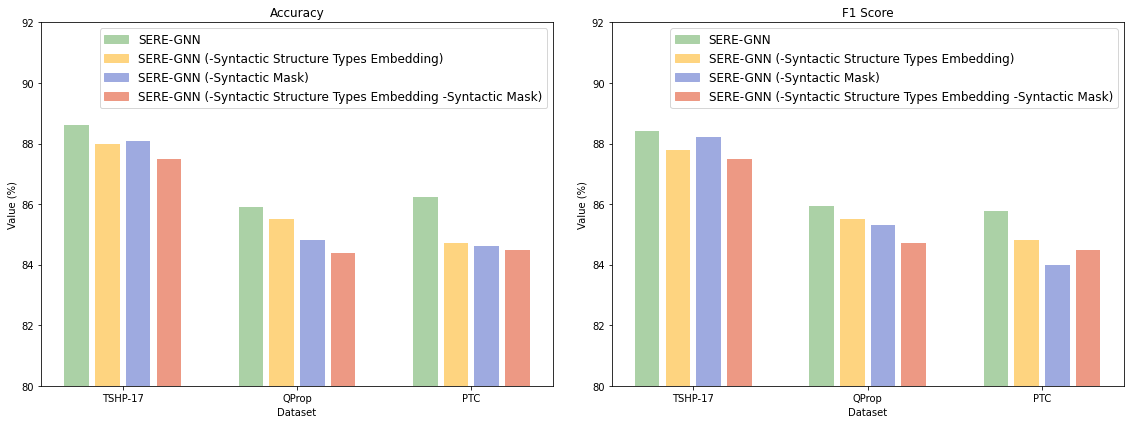

In [13]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# -------------------------
plt.rcParams["font.family"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False

datasets = ['TSHP-17', 'QProp', 'PTC']
accuracy_values = {
    'SERE-GNN': [88.61, 85.89, 86.25],
    'SERE-GNN (-Syntactic Structure Types Embedding)': [88.0, 85.5, 84.7],
    'SERE-GNN (-Syntactic Mask)': [88.1, 84.8, 84.6],
    'SERE-GNN (-Syntactic Structure Types Embedding -Syntactic Mask)': [87.5, 84.4, 84.5]
}
f1_values = {
    'SERE-GNN': [88.43, 85.93, 85.77],
    'SERE-GNN (-Syntactic Structure Types Embedding)': [87.8, 85.5, 84.8],
    'SERE-GNN (-Syntactic Mask)': [88.2, 85.3, 84.0],
    'SERE-GNN (-Syntactic Structure Types Embedding -Syntactic Mask)': [87.5, 84.7, 84.5]
}

# -------------------------
bar_width = 0.12
gap_within_group = 0.03
group_gap = 0.25
n_models = len(accuracy_values)
n_datasets = len(datasets)

x_positions = []
for i in range(n_datasets):
    group_start = i * (n_models*(bar_width+gap_within_group) + group_gap)
    for j in range(n_models):
        x_positions.append(group_start + j*(bar_width+gap_within_group))

# -------------------------
# 新颜色
colors = ['#ABD1A6', '#FED480', '#9EAAE0', '#ED9984']
legend_patches = [Patch(color=colors[i], label=list(accuracy_values.keys())[i]) for i in range(n_models)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# Accuracy
ax1.bar(x_positions,
        [val for dataset in datasets for val in [accuracy_values[key][datasets.index(dataset)] for key in accuracy_values.keys()]],
        width=bar_width, color=colors*len(datasets))
ax1.set_xticks([i*(n_models*(bar_width+gap_within_group)+group_gap) + (n_models-1)/2*(bar_width+gap_within_group) for i in range(n_datasets)])
ax1.set_xticklabels(datasets)
ax1.set_ylabel('Value (%)')
ax1.set_xlabel('Dataset')
ax1.set_title('Accuracy')
ax1.set_ylim(80,92)
#ax1.grid(axis='y', linestyle='--', alpha=0.5)   虚线
ax1.legend(handles=legend_patches, fontsize=12)

# F1 Score
ax2.bar(x_positions,
        [val for dataset in datasets for val in [f1_values[key][datasets.index(dataset)] for key in f1_values.keys()]],
        width=bar_width, color=colors*len(datasets))
ax2.set_xticks([i*(n_models*(bar_width+gap_within_group)+group_gap) + (n_models-1)/2*(bar_width+gap_within_group) for i in range(n_datasets)])
ax2.set_xticklabels(datasets)
ax2.set_ylabel('Value (%)')
ax2.set_xlabel('Dataset')
ax2.set_title('F1 Score')
ax2.set_ylim(80,92)
#ax2.grid(axis='y', linestyle='--', alpha=0.5)    虚线
ax2.legend(handles=legend_patches, fontsize=12)

plt.tight_layout()
plt.show()

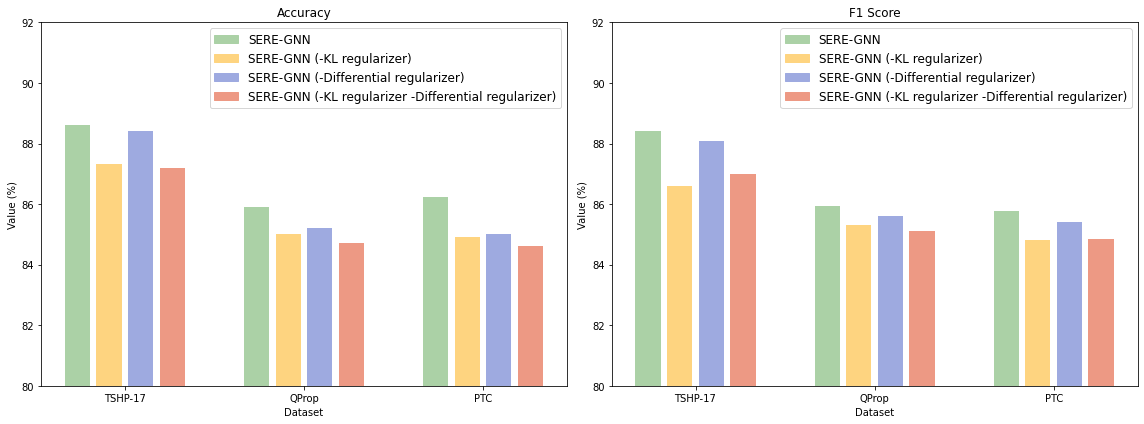

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# -------------------------
plt.rcParams["font.family"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False

datasets = ['TSHP-17', 'QProp', 'PTC']
accuracy_values = {
    'SERE-GNN': [88.61, 85.89, 86.25],
    'SERE-GNN (-KL regularizer)': [87.31, 85.0, 84.9],
    'SERE-GNN (-Differential regularizer)': [88.43, 85.2, 85],
    'SERE-GNN (-KL regularizer -Differential regularizer)': [87.2, 84.7, 84.6]
}
f1_values = {
    'SERE-GNN': [88.43, 85.93, 85.77],
    'SERE-GNN (-KL regularizer)': [86.6, 85.3, 84.8],
    'SERE-GNN (-Differential regularizer)':[88.1, 85.6, 85.4],
    'SERE-GNN (-KL regularizer -Differential regularizer)': [87.0, 85.1, 84.85]
}

# -------------------------
bar_width = 0.12
gap_within_group = 0.03
group_gap = 0.25
n_models = len(accuracy_values)
n_datasets = len(datasets)

x_positions = []
for i in range(n_datasets):
    group_start = i * (n_models*(bar_width+gap_within_group) + group_gap)
    for j in range(n_models):
        x_positions.append(group_start + j*(bar_width+gap_within_group))

# -------------------------
# 新颜色
colors = ['#ABD1A6', '#FED480', '#9EAAE0', '#ED9984']
legend_patches = [Patch(color=colors[i], label=list(accuracy_values.keys())[i]) for i in range(n_models)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# Accuracy
ax1.bar(x_positions,
        [val for dataset in datasets for val in [accuracy_values[key][datasets.index(dataset)] for key in accuracy_values.keys()]],
        width=bar_width, color=colors*len(datasets))
ax1.set_xticks([i*(n_models*(bar_width+gap_within_group)+group_gap) + (n_models-1)/2*(bar_width+gap_within_group) for i in range(n_datasets)])
ax1.set_xticklabels(datasets)
ax1.set_ylabel('Value (%)')
ax1.set_xlabel('Dataset')
ax1.set_title('Accuracy')
ax1.set_ylim(80,92)
#ax1.grid(axis='y', linestyle='--', alpha=0.5)   虚线
ax1.legend(handles=legend_patches, fontsize=12)

# F1 Score
ax2.bar(x_positions,
        [val for dataset in datasets for val in [f1_values[key][datasets.index(dataset)] for key in f1_values.keys()]],
        width=bar_width, color=colors*len(datasets))
ax2.set_xticks([i*(n_models*(bar_width+gap_within_group)+group_gap) + (n_models-1)/2*(bar_width+gap_within_group) for i in range(n_datasets)])
ax2.set_xticklabels(datasets)
ax2.set_ylabel('Value (%)')
ax2.set_xlabel('Dataset')
ax2.set_title('F1 Score')
ax2.set_ylim(80,92)
#ax2.grid(axis='y', linestyle='--', alpha=0.5)    虚线
ax2.legend(handles=legend_patches, fontsize=12)

plt.tight_layout()
plt.show()

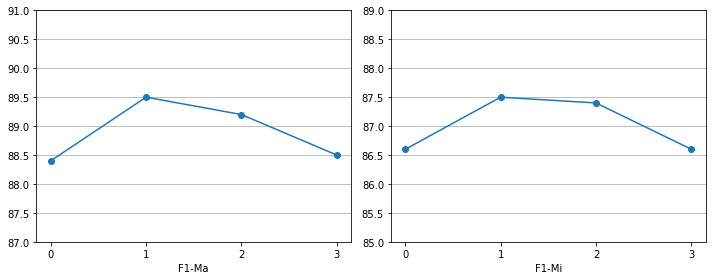

In [18]:
import matplotlib.pyplot as plt

plt.close('all')

[88.61, 85.89, 86.25]


# 数据
x = [0, 1, 2, 3, 4]
Acc = [88.4, 89.5, 89.2, 88.5]
f1_mi = [86.6, 87.5, 87.4, 86.6]

plt.figure(figsize=(10, 4))

# ---------------------------
# 左图：Acc
# ---------------------------
plt.subplot(1, 2, 1)
plt.plot(x, Acc, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("F1-Ma")
plt.ylim(87, 91)

plt.grid(axis='y')   # 只显示横线

# ---------------------------
# 右图：F1-Mi
# ---------------------------
plt.subplot(1, 2, 2)
plt.plot(x, f1_mi, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("F1-Mi")
plt.ylim(85, 89)

plt.grid(axis='y')   # 只显示横线

plt.tight_layout()
plt.show()




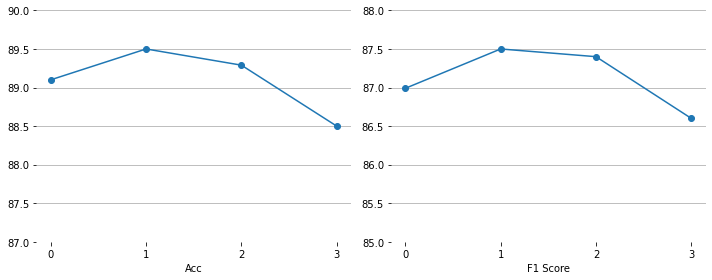

In [24]:
import matplotlib.pyplot as plt

plt.close('all')

# 数据
x = [0, 1, 2, 3]
Acc = [89.1, 89.5, 89.29, 88.5]
f1_mi = [86.99, 87.5, 87.4, 86.6]

plt.figure(figsize=(10, 4))

# ---------------------------
# 左图
# ---------------------------
plt.subplot(1, 2, 1)
plt.plot(x, Acc, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("Acc")
plt.ylim(87, 90)

plt.grid(axis='y')   # 只画横线

# 去掉外边框
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# ---------------------------
# 右图
# ---------------------------
plt.subplot(1, 2, 2)
plt.plot(x, f1_mi, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("F1 Score")
plt.ylim(85, 88)

plt.grid(axis='y')   # 只画横线

# 去掉外边框
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.
findfont: Font family ['Arial'] not found. Falling back to DejaVu Sans.


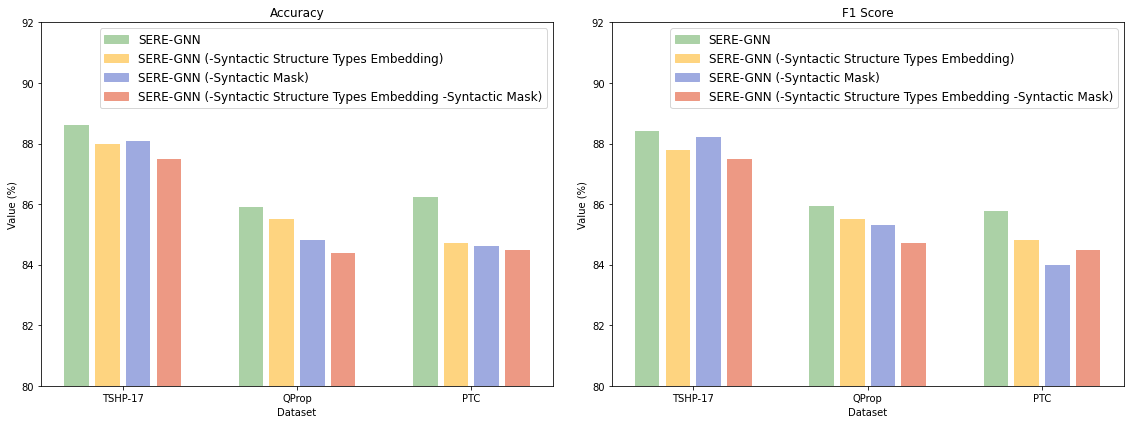

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# -------------------------
plt.rcParams["font.family"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False

datasets = ['TSHP-17', 'QProp', 'PTC']
accuracy_values = {
    'SERE-GNN': [88.61, 85.89, 86.25],
    'SERE-GNN (-Syntactic Structure Types Embedding)': [88.0, 85.5, 84.7],
    'SERE-GNN (-Syntactic Mask)': [88.1, 84.8, 84.6],
    'SERE-GNN (-Syntactic Structure Types Embedding -Syntactic Mask)': [87.5, 84.4, 84.5]
}
f1_values = {
    'SERE-GNN': [88.43, 85.93, 85.77],
    'SERE-GNN (-Syntactic Structure Types Embedding)': [87.8, 85.5, 84.8],
    'SERE-GNN (-Syntactic Mask)': [88.2, 85.3, 84.0],
    'SERE-GNN (-Syntactic Structure Types Embedding -Syntactic Mask)': [87.5, 84.7, 84.5]
}

# -------------------------
bar_width = 0.12
gap_within_group = 0.03
group_gap = 0.25
n_models = len(accuracy_values)
n_datasets = len(datasets)

x_positions = []
for i in range(n_datasets):
    group_start = i * (n_models*(bar_width+gap_within_group) + group_gap)
    for j in range(n_models):
        x_positions.append(group_start + j*(bar_width+gap_within_group))

# -------------------------
# 新颜色
colors = ['#ABD1A6', '#FED480', '#9EAAE0', '#ED9984']
legend_patches = [Patch(color=colors[i], label=list(accuracy_values.keys())[i]) for i in range(n_models)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16,6))

# Accuracy
ax1.bar(x_positions,
        [val for dataset in datasets for val in [accuracy_values[key][datasets.index(dataset)] for key in accuracy_values.keys()]],
        width=bar_width, color=colors*len(datasets))
ax1.set_xticks([i*(n_models*(bar_width+gap_within_group)+group_gap) + (n_models-1)/2*(bar_width+gap_within_group) for i in range(n_datasets)])
ax1.set_xticklabels(datasets)
ax1.set_ylabel('Value (%)')
ax1.set_xlabel('Dataset')
ax1.set_title('Accuracy')
ax1.set_ylim(80,92)
#ax1.grid(axis='y', linestyle='--', alpha=0.5)   虚线
ax1.legend(handles=legend_patches, fontsize=12)

# F1 Score
ax2.bar(x_positions,
        [val for dataset in datasets for val in [f1_values[key][datasets.index(dataset)] for key in f1_values.keys()]],
        width=bar_width, color=colors*len(datasets))
ax2.set_xticks([i*(n_models*(bar_width+gap_within_group)+group_gap) + (n_models-1)/2*(bar_width+gap_within_group) for i in range(n_datasets)])
ax2.set_xticklabels(datasets)
ax2.set_ylabel('Value (%)')
ax2.set_xlabel('Dataset')
ax2.set_title('F1 Score')
ax2.set_ylim(80,92)
#ax2.grid(axis='y', linestyle='--', alpha=0.5)    虚线
ax2.legend(handles=legend_patches, fontsize=12)

plt.tight_layout()
plt.show()

In [ ]:
原始数据[88.61, 85.89, 86.25]
[88.43, 85.93, 85.77]

无句法掩码的数据[88.1, 84.8, 84.6]
[88.2, 85.3, 84.0]

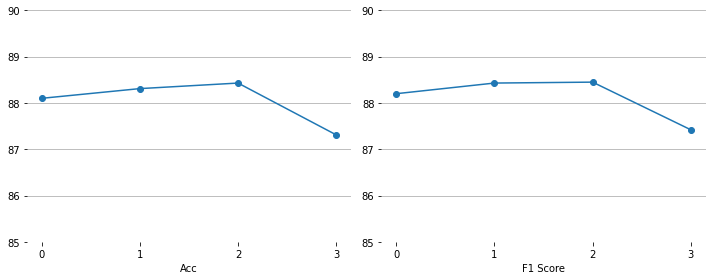

In [8]:
import matplotlib.pyplot as plt

plt.close('all')

# 数据
x = [0, 1, 2, 3]
Acc = [88.1, 88.31, 88.43, 87.31]
f1_mi = [88.2, 88.43, 88.45, 87.42]

plt.figure(figsize=(10, 4))

# ---------------------------
# 左图
# ---------------------------
plt.subplot(1, 2, 1)
plt.plot(x, Acc, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("Acc")
plt.ylim(85, 90)

plt.grid(axis='y')   # 只画横线

# 去掉外边框
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# ---------------------------
# 右图
# ---------------------------
plt.subplot(1, 2, 2)
plt.plot(x, f1_mi, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("F1 Score")
plt.ylim(85, 90)

plt.grid(axis='y')   # 只画横线

# 去掉外边框
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()


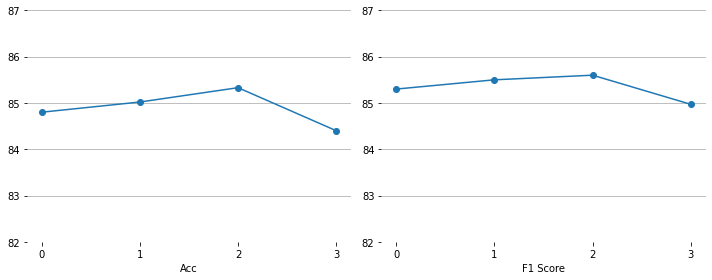

In [12]:
import matplotlib.pyplot as plt

plt.close('all')

# 数据
x = [0, 1, 2, 3]
Acc = [84.8, 85.02, 85.33, 84.4]
f1_mi = [85.3, 85.5, 85.6, 84.97]

plt.figure(figsize=(10, 4))

# ---------------------------
# 左图
# ---------------------------
plt.subplot(1, 2, 1)
plt.plot(x, Acc, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("Acc")
plt.ylim(82, 87)

plt.grid(axis='y')   # 只画横线

# 去掉外边框
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# ---------------------------
# 右图
# ---------------------------
plt.subplot(1, 2, 2)
plt.plot(x, f1_mi, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("F1 Score")
plt.ylim(82, 87)

plt.grid(axis='y')   # 只画横线

# 去掉外边框
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

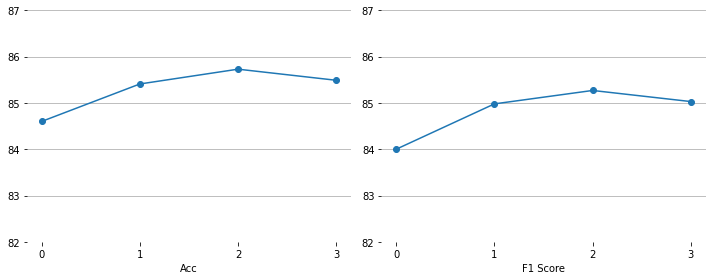

In [13]:
import matplotlib.pyplot as plt

plt.close('all')

# 数据
x = [0, 1, 2, 3]
Acc = [84.6, 85.41, 85.73, 85.49]
f1_mi = [84.0, 84.98, 85.27, 85.03]

plt.figure(figsize=(10, 4))

# ---------------------------
# 左图
# ---------------------------
plt.subplot(1, 2, 1)
plt.plot(x, Acc, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("Acc")
plt.ylim(82, 87)

plt.grid(axis='y')   # 只画横线

# 去掉外边框
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# ---------------------------
# 右图
# ---------------------------
plt.subplot(1, 2, 2)
plt.plot(x, f1_mi, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("F1 Score")
plt.ylim(82, 87)

plt.grid(axis='y')   # 只画横线

# 去掉外边框
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
原始数据[88.61, 85.89, 86.25]
[88.43, 85.93, 85.77]

无句法掩码的数据[88.1, 84.8, 84.6]
[88.2, 85.3, 84.0]

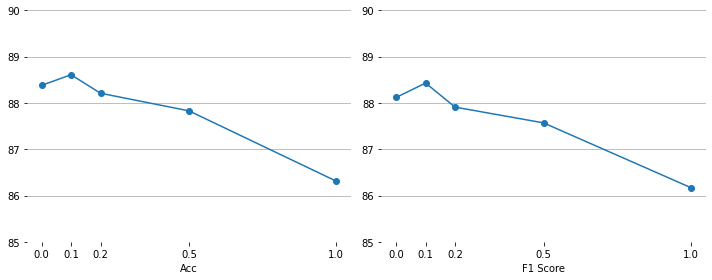

In [20]:
import matplotlib.pyplot as plt
86.31
plt.close('all')

# 数据
x = [0, 0.1, 0.2, 0.5, 1]
Acc = [88.38, 88.61, 88.21, 87.83, 86.31]
f1_mi = [88.12, 88.43, 87.91, 87.57, 86.17]

plt.figure(figsize=(10, 4))

# ---------------------------
# 左图
# ---------------------------
plt.subplot(1, 2, 1)
plt.plot(x, Acc, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("Acc")
plt.ylim(85, 90)

plt.grid(axis='y')   # 只画横线

# 去掉外边框
for spine in plt.gca().spines.values():
    spine.set_visible(False)

# ---------------------------
# 右图
# ---------------------------
plt.subplot(1, 2, 2)
plt.plot(x, f1_mi, marker='o', linewidth=1.5)
plt.xticks(x)
plt.xlabel("F1 Score")
plt.ylim(85, 90)

plt.grid(axis='y')   # 只画横线

# 去掉外边框
for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()

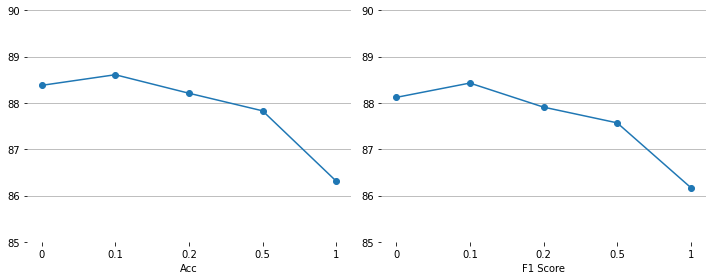

In [21]:
import matplotlib.pyplot as plt

plt.close('all')

# 原始 x（仅用于显示）
x_labels = [0, 0.1, 0.2, 0.5, 1]
x_pos = range(len(x_labels))  # 等间距位置

Acc = [88.38, 88.61, 88.21, 87.83, 86.31]
f1_mi = [88.12, 88.43, 87.91, 87.57, 86.17]

plt.figure(figsize=(10, 4))

# ---------------------------
# 左图
# ---------------------------
plt.subplot(1, 2, 1)
plt.plot(x_pos, Acc, marker='o', linewidth=1.5)
plt.xticks(x_pos, x_labels)
plt.xlabel("Acc")
plt.ylim(85, 90)
plt.grid(axis='y')

for spine in plt.gca().spines.values():
    spine.set_visible(False)

# ---------------------------
# 右图
# ---------------------------
plt.subplot(1, 2, 2)
plt.plot(x_pos, f1_mi, marker='o', linewidth=1.5)
plt.xticks(x_pos, x_labels)
plt.xlabel("F1 Score")
plt.ylim(85, 90)
plt.grid(axis='y')

for spine in plt.gca().spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()
